# Farmetry 데이터 적용 — 다음 적정 온·습도



In [3]:
# 데이터 로드 · 이미지 매칭
import sys
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

KST = timezone(timedelta(hours=9))
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FARMETRY = ROOT
DATA_DIR = FARMETRY / "data" / "farmetry"
IMG_DIR = DATA_DIR / "Farmetry_image"
OUT = DATA_DIR
SCRIPTS = FARMETRY / "scripts"
sys.path.insert(0, str(SCRIPTS))

EXCEL_PATH = next(DATA_DIR.glob("*.xlsx"))
N_TRIALS = 120


def _row_datetime(row: pd.Series) -> pd.Timestamp:
    if pd.notna(row.get("image_id")):
        ts = datetime.fromtimestamp(int(row["image_id"]), tz=KST)
        return pd.Timestamp(ts.replace(tzinfo=None))
    d = pd.to_datetime(row["date"])
    t = row["time"]
    if pd.isna(t):
        return pd.NaT
    if hasattr(t, "time"):
        return pd.Timestamp.combine(d.date(), t.time())
    return pd.to_datetime(f"{d.date()} {t}")


raw = pd.read_excel(EXCEL_PATH)
raw.columns = ["date", "time", "image_id", "temp_c", "humidity_pct"]
raw["datetime"] = raw.apply(_row_datetime, axis=1)
raw["date_only"] = pd.to_datetime(raw["datetime"]).dt.date

img_paths = {int(p.stem): p for p in IMG_DIR.rglob("*.jpg")}
raw["image_path"] = raw["image_id"].apply(
    lambda x: str(img_paths[int(x)].relative_to(FARMETRY)) if pd.notna(x) and int(x) in img_paths else None
)

excel_ids = set(raw["image_id"].dropna().astype(int))
matched = excel_ids & set(img_paths)
print(f"엑셀: {EXCEL_PATH.name} | 시간별 {len(raw)}행")
print(f"이미지 {len(img_paths)}장 | 엑셀 ID 매칭 {len(matched)}/{len(excel_ids)}")

daily = (
    raw.dropna(subset=["datetime"])
    .groupby("date_only", as_index=False)
    .agg(
        AirTemp_C_min=("temp_c", "min"),
        AirHum_pct_min=("humidity_pct", "min"),
        n_hours=("temp_c", "count"),
        image_ids=("image_id", lambda s: [int(x) for x in s.dropna().astype(int)]),
    )
)
daily["date"] = daily["date_only"].astype(str)
daily.to_csv(OUT / "office_env_daily.csv", index=False, encoding="utf-8-sig")
print("\n=== 일별 온습도 ===")
print(daily[["date", "AirTemp_C_min", "AirHum_pct_min", "n_hours"]].to_string(index=False))

snapshots = raw[raw["image_id"].notna()].copy()
snapshots["image_id"] = snapshots["image_id"].astype(int)
print("\n=== 이미지 촬영 시점 ===")
print(
    snapshots[["image_id", "datetime", "temp_c", "humidity_pct", "image_path"]]
    .rename(columns={"temp_c": "기온", "humidity_pct": "습도"})
    .to_string(index=False)
)

엑셀: 사무실 온습도 데이터.xlsx | 시간별 61행
이미지 32장 | 엑셀 ID 매칭 4/4

=== 일별 온습도 ===
      date  AirTemp_C_min  AirHum_pct_min  n_hours
2026-07-01           23.1            58.0       15
2026-07-02           22.7            56.0       24
2026-07-03           22.9            61.0       19

=== 이미지 촬영 시점 ===
  image_id            datetime   기온   습도                                  image_path
1782864001 2026-07-01 09:00:01 25.7 71.0 data\farmetry\Farmetry_image\1782864001.jpg
1782914401 2026-07-01 23:00:01 28.2 59.0 data\farmetry\Farmetry_image\1782914401.jpg
1782986400 2026-07-02 19:00:00 26.8 66.0 data\farmetry\Farmetry_image\1782986400.jpg
1783072801 2026-07-03 19:00:01 26.1  NaN data\farmetry\Farmetry_image\1783072801.jpg


모델: Ridge (CV) | 탐색: optuna (120 trials) | 상추 학습 범위 p10~p90

=== 다음 적정 온·습도 (최신일 기준) ===
현재  : 기온 22.9°C, 습도 61.0%
다음  : 기온 22.4°C (낮추는 방향), 습도 58.0% (낮추는 방향)
장기  : 기온 18.95°C, 습도 34.41%
예측 생장: 2.804 → 다음 2.923 (+0.119) → 목표 3.939 (+1.134) g/일
※ 사무실 습도(56~77%)는 학습 범위(34~47%)보다 높음 → 습도 낮추기 권고

저장: c:\Users\msyu7\Desktop\HYU\Farmetry-VisionAI\data\farmetry\office_control_recommendation.csv


,label,현재_기온,다음_기온,목표_기온,현재_습도,다음_습도,목표_습도,현재_예측_g일,다음_예측_g일,목표_예측_g일
0,최신일 2026-07-03,22.9,22.4,18.95,61.0,58.0,34.41,2.804,2.923,3.939
1,이미지 1782864001,25.7,25.2,18.97,71.0,68.0,34.38,2.590,2.709,3.945
2,이미지 1782914401,28.2,27.7,18.97,59.0,56.0,34.41,3.794,3.913,3.943
3,이미지 1782986400,26.8,26.3,18.89,66.0,63.0,34.39,3.101,3.220,3.930


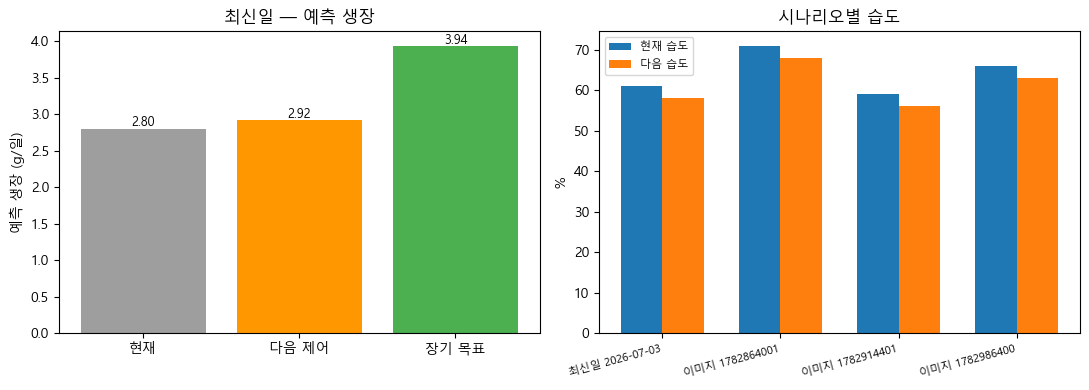

In [4]:
# Ridge 생장 모델 + Optuna (02번 스크립트 재사용)
import numpy as np
from lettuce_growth_env_optuna import run_env_control_optuna
from lettuce_growth_model import load_merged, train_growth_model

merged = load_merged()
bundle, lag_df = train_growth_model(merged)
CONTROL = ["AirHum_pct_min", "AirTemp_C_min"]


def recommend_office(temp_min: float, hum_min: float, label: str) -> dict:
    res = run_env_control_optuna(
        bundle=bundle,
        lag_df=lag_df,
        merged=merged,
        n_trials=N_TRIALS,
        control_features=CONTROL,
        env_override={"AirTemp_C_min": float(temp_min), "AirHum_pct_min": float(hum_min)},
        scenario_name=label,
        verbose=False,
    )
    ctrl = res["control_df"].set_index("feature")
    return {
        "label": label,
        "method": res["search_method"],
        "현재_기온": round(ctrl.loc["AirTemp_C_min", "current_value"], 2),
        "다음_기온": round(ctrl.loc["AirTemp_C_min", "next_control_value"], 2),
        "목표_기온": round(ctrl.loc["AirTemp_C_min", "bayesian_target"], 2),
        "현재_습도": round(ctrl.loc["AirHum_pct_min", "current_value"], 2),
        "다음_습도": round(ctrl.loc["AirHum_pct_min", "next_control_value"], 2),
        "목표_습도": round(ctrl.loc["AirHum_pct_min", "bayesian_target"], 2),
        "기온_조언": ctrl.loc["AirTemp_C_min", "advice"],
        "습도_조언": ctrl.loc["AirHum_pct_min", "advice"],
        "현재_예측_g일": round(res["current_pred_g"], 3),
        "다음_예측_g일": round(res["next_pred_g"], 3),
        "목표_예측_g일": round(res["target_pred_g"], 3),
        "생장_증가_다음_g": round(res["next_pred_g"] - res["current_pred_g"], 3),
        "생장_증가_목표_g": round(res["target_pred_g"] - res["current_pred_g"], 3),
    }


scenarios = [(daily.iloc[-1]["AirTemp_C_min"], daily.iloc[-1]["AirHum_pct_min"], f"최신일 {daily.iloc[-1]['date']}")]
for _, row in snapshots.iterrows():
    if pd.notna(row["humidity_pct"]):
        scenarios.append((float(row["temp_c"]), float(row["humidity_pct"]), f"이미지 {int(row['image_id'])}"))

rec_df = pd.DataFrame([recommend_office(t, h, lab) for t, h, lab in scenarios])
rec_df.to_csv(OUT / "office_control_recommendation.csv", index=False, encoding="utf-8-sig")

main = rec_df.iloc[0]
print(f"모델: Ridge (CV) | 탐색: {main['method']} ({N_TRIALS} trials) | 상추 학습 범위 p10~p90")
print("\n=== 다음 적정 온·습도 (최신일 기준) ===")
print(f"현재  : 기온 {main['현재_기온']}°C, 습도 {main['현재_습도']}%")
print(f"다음  : 기온 {main['다음_기온']}°C ({main['기온_조언']}), 습도 {main['다음_습도']}% ({main['습도_조언']})")
print(f"장기  : 기온 {main['목표_기온']}°C, 습도 {main['목표_습도']}%")
print(
    f"예측 생장: {main['현재_예측_g일']} → 다음 {main['다음_예측_g일']} "
    f"(+{main['생장_증가_다음_g']}) → 목표 {main['목표_예측_g일']} (+{main['생장_증가_목표_g']}) g/일"
)
print("※ 사무실 습도(56~77%)는 학습 범위(34~47%)보다 높음 → 습도 낮추기 권고")
print(f"\n저장: {OUT / 'office_control_recommendation.csv'}")

show = rec_df[
    [
        "label", "현재_기온", "다음_기온", "목표_기온",
        "현재_습도", "다음_습도", "목표_습도",
        "현재_예측_g일", "다음_예측_g일", "목표_예측_g일",
    ]
]
display(show)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ["현재", "다음 제어", "장기 목표"]
vals = [main["현재_예측_g일"], main["다음_예측_g일"], main["목표_예측_g일"]]
axes[0].bar(labels, vals, color=["#9e9e9e", "#ff9800", "#4caf50"])
axes[0].set_ylabel("예측 생장 (g/일)")
axes[0].set_title("최신일 — 예측 생장")
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)

x = np.arange(len(rec_df))
w = 0.35
axes[1].bar(x - w / 2, rec_df["현재_습도"], width=w, label="현재 습도")
axes[1].bar(x + w / 2, rec_df["다음_습도"], width=w, label="다음 습도")
axes[1].set_xticks(x)
axes[1].set_xticklabels(rec_df["label"], rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("%")
axes[1].set_title("시나리오별 습도")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()